# Cross-Border Arbitrage Simulator

This notebook contains the main logic for the Cross-Border Arbitrage Simulator. It includes sections for importing libraries, fetching data, processing it, and visualizing results, all while using Shopify's ticker for demonstration purposes.

In [12]:
# 2) Cell 1: Imports and Global Parameters
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from datetime import datetime, timedelta

# Parameters and fees
initial_capital = 10_000
cad_fee = 30              # flat CAD fee on CAD side
usd_fee_rate = 0.0003     # fee rate on USD side (converted to CAD)

# Company tickers
domestic_ticker = "SHOP.TO"   # TSX (CAD)
foreign_ticker = "SHOP"       # NYSE (USD)

# Time frame: 1 year ago → yesterday
end_date = datetime.today() - timedelta(days=1)
start_date = end_date - timedelta(days=365)

print(f"Date window: {start_date.date()} to {end_date.date()}")

Date window: 2025-03-12 to 2026-03-12


In [13]:
# 3) Cell 2: Ticker Metadata Fetch
domestic_info = yf.Ticker(domestic_ticker).info
foreign_info = yf.Ticker(foreign_ticker).info

name = domestic_info.get("longName", "N/A")
industry = domestic_info.get("industry", "N/A")
sector = domestic_info.get("sector", "N/A")
location = f"{domestic_info.get('city', '')}, {domestic_info.get('country', '')}"
domestic_exchange = domestic_info.get("exchange", "N/A")
foreign_exchange = foreign_info.get("exchange", "N/A")

company_df = pd.DataFrame([{
    "name": name,
    "domestic_ticker": domestic_ticker,
    "industry": industry,
    "sector": sector,
    "location": location,
    "domestic_exchange": domestic_exchange,
    "foreign_exchange": foreign_exchange,
    "foreign_ticker": foreign_ticker
}])

print("Company / Exchange Info:")
display(company_df)

Company / Exchange Info:


,name,domestic_ticker,industry,sector,location,domestic_exchange,foreign_exchange,foreign_ticker
0,Shopify Inc.,SHOP.TO,Software - Application,Technology,"Ottawa, Canada",TOR,NMS,SHOP


In [14]:
# 4) Cell 3: FX Rate Helper Function and Data Pull
def get_rate(ex_ticker, start_date, end_date):
    ex_rate = yf.Ticker(ex_ticker)
    ex_hist = ex_rate.history(start=start_date, end=end_date)
    ex_df = pd.DataFrame({"Exchange Rate": ex_hist["Close"]})
    ex_df.index = pd.to_datetime(ex_df.index.date)  # normalize to date only
    return ex_df

exchange_df = get_rate("CADUSD=X", start_date, end_date)  # USD per 1 CAD
exchange_df.head()

,Exchange Rate
2025-03-12,0.692885
2025-03-13,0.696296
2025-03-14,0.693202
2025-03-17,0.695933
2025-03-18,0.699540


In [15]:
# 5) Cell 4: Price Download, Cleanup, and Merge
prices = yf.download(
    [domestic_ticker, foreign_ticker],
    start=start_date,
    end=end_date,
    auto_adjust=True
)["Close"]

prices.index = pd.to_datetime(prices.index.date)

prices = prices.rename(columns={
    domestic_ticker: "Close_domestic",   # CAD
    foreign_ticker: "Close_foreign"      # USD
})

# Merge with FX
merged = prices.join(exchange_df, how="inner")
merged["Exchange Rate"] = merged["Exchange Rate"].ffill()

# Implied CAD price of US side
merged["CAD_implied_close_price"] = merged["Close_foreign"] / merged["Exchange Rate"]

merged_portfolio = merged[[
    "Close_domestic",
    "CAD_implied_close_price",
    "Close_foreign",
    "Exchange Rate"
]].dropna().copy()

print("Merged portfolio preview:")
display(merged_portfolio.head())

[*********************100%***********************]  2 of 2 completed

Merged portfolio preview:


,Close_domestic,CAD_implied_close_price,Close_foreign,Exchange Rate
2025-03-12,138.839996,139.315954,96.529999,0.692885
2025-03-13,130.720001,130.102636,90.589996,0.696296
2025-03-14,136.330002,136.828715,94.849998,0.693202
2025-03-17,138.020004,138.792106,96.589996,0.695933
2025-03-18,134.380005,134.388243,94.010002,0.699540


In [16]:
# 6) Cell 5: Arbitrage Strategy Function
def buy_sell_compounding(df, initial_capital, cad_fee, usd_fee_rate, min_rel_spread=0.0):
    capital = float(initial_capital)
    dates, capitals, trades = [], [], []

    df = df.dropna(subset=[
        "Close_domestic",
        "CAD_implied_close_price",
        "Close_foreign",
        "Exchange Rate"
    ])

    for d in df.index:
        actual = df.loc[d, "Close_domestic"]                # CAD
        implied = df.loc[d, "CAD_implied_close_price"]      # CAD
        implied_in_usd = df.loc[d, "Close_foreign"]         # USD
        cadusd = df.loc[d, "Exchange Rate"]                 # USD per CAD
        executed = 0

        if cadusd > 0:
            cad_per_usd = 1.0 / cadusd
            spread = abs(actual - implied)
            lower = min(actual, implied)

            # Relative spread filter
            if lower > 0 and (spread / lower) >= min_rel_spread:
                num_shares = int(np.floor(capital / lower))
                if num_shares > 0:
                    usd_notional = num_shares * implied_in_usd
                    usd_fee_cad = usd_notional * usd_fee_rate * cad_per_usd
                    fees_cad = cad_fee + usd_fee_cad

                    gross_edge_cad = spread * num_shares
                    if gross_edge_cad > fees_cad:
                        capital += gross_edge_cad - fees_cad
                        executed = 1

        dates.append(d)
        capitals.append(capital)
        trades.append(executed)

    equity_df = pd.DataFrame(
        {"Equity": capitals, "TradesExecuted": trades},
        index=pd.to_datetime(dates)
    )
    equity_df["Profit"] = equity_df["Equity"] - initial_capital
    return equity_df

In [17]:
# 7) Cell 6: Run Backtest + Performance Stats + Benchmarks
min_rel_spread = 0.001  # 10 bps

equity_df = buy_sell_compounding(
    merged_portfolio,
    initial_capital,
    cad_fee,
    usd_fee_rate,
    min_rel_spread=min_rel_spread
)

def perf_stats_from_curve(curve: pd.Series, initial_capital: float, ann: int = 252) -> pd.Series:
    r = curve.pct_change().dropna()
    n = len(r)

    years = max((curve.index[-1] - curve.index[0]).days / 365.25, 1 / 365.25)
    cagr = (curve.iloc[-1] / initial_capital) ** (1 / years) - 1
    vol = r.std() * np.sqrt(ann) if n > 1 else np.nan
    sharpe = (r.mean() * ann) / vol if (vol is not np.nan and vol and vol > 0) else np.nan
    dd = curve / curve.cummax() - 1
    mdd = dd.min()

    return pd.Series({
        "Final Equity": curve.iloc[-1],
        "Total Return": (curve.iloc[-1] / initial_capital) - 1,
        "CAGR": cagr,
        "Volatility": vol,
        "Sharpe": sharpe,
        "Max Drawdown": mdd
    })

# Benchmarks (same capital, buy-and-hold)
bench_df = pd.DataFrame(index=merged_portfolio.index)
bench_df["Strategy"] = equity_df["Equity"].reindex(bench_df.index).ffill()
bench_df["SHOP.TO Buy&Hold"] = initial_capital * (
    merged_portfolio["Close_domestic"] / merged_portfolio["Close_domestic"].iloc[0]
)
bench_df["SHOP (USD->CAD) Buy&Hold"] = initial_capital * (
    merged_portfolio["CAD_implied_close_price"] / merged_portfolio["CAD_implied_close_price"].iloc[0]
)
bench_df = bench_df.dropna()

# Stats table
stats_df = pd.DataFrame({
    col: perf_stats_from_curve(bench_df[col], initial_capital)
    for col in bench_df.columns
}).T

# Strategy-only execution metrics
win_rate = (equity_df["Equity"].diff() > 0).mean()
turnover = equity_df["TradesExecuted"].sum() / len(equity_df)

print(f"Backtest window: {equity_df.index.min().date()} → {equity_df.index.max().date()}")
print(f"Trades executed: {int(equity_df['TradesExecuted'].sum())}")
print(f"Win rate (days with positive PnL): {win_rate:.2%}")
print(f"Turnover (trades/day): {turnover:.4f}")

display(stats_df.style.format({
    "Final Equity": "{:,.2f}",
    "Total Return": "{:.2%}",
    "CAGR": "{:.2%}",
    "Volatility": "{:.2%}",
    "Sharpe": "{:.2f}",
    "Max Drawdown": "{:.2%}"
}))

Backtest window: 2025-03-12 → 2026-03-11
Trades executed: 81
Win rate (days with positive PnL): 32.65%
Turnover (trades/day): 0.3306


,Final Equity,Total Return,CAGR,Volatility,Sharpe,Max Drawdown
Strategy,"11,725.67",17.26%,17.32%,2.23%,7.38,0.00%
SHOP.TO Buy&Hold,"12,674.30",26.74%,26.85%,62.53%,0.70,-39.71%
SHOP (USD->CAD) Buy&Hold,"12,627.82",26.28%,26.38%,62.94%,0.69,-40.00%


In [18]:
# 10) Cell 9: Per-Trade Log
def build_trade_log(df, initial_capital, cad_fee, usd_fee_rate, min_rel_spread=0.0):
    capital = float(initial_capital)
    records = []

    df = df.dropna(subset=[
        "Close_domestic",
        "CAD_implied_close_price",
        "Close_foreign",
        "Exchange Rate"
    ])

    for d in df.index:
        actual   = df.loc[d, "Close_domestic"]
        implied  = df.loc[d, "CAD_implied_close_price"]
        usd_price = df.loc[d, "Close_foreign"]
        cadusd   = df.loc[d, "Exchange Rate"]

        if cadusd <= 0:
            continue

        cad_per_usd = 1.0 / cadusd
        spread      = abs(actual - implied)
        lower       = min(actual, implied)

        if lower > 0 and (spread / lower) >= min_rel_spread:
            num_shares   = int(np.floor(capital / lower))
            if num_shares > 0:
                usd_notional  = num_shares * usd_price
                usd_fee_cad   = usd_notional * usd_fee_rate * cad_per_usd
                fees_cad      = cad_fee + usd_fee_cad
                gross_edge    = spread * num_shares
                net_profit    = gross_edge - fees_cad

                if net_profit > 0:
                    direction = "Buy TSX / Sell NYSE" if actual < implied else "Buy NYSE / Sell TSX"
                    capital  += net_profit
                    records.append({
                        "Date":              d,
                        "Direction":         direction,
                        "TSX Price (CAD)":   round(actual, 4),
                        "NYSE Implied (CAD)": round(implied, 4),
                        "Spread %":          round(spread / lower * 100, 4),
                        "Shares":            num_shares,
                        "Gross Edge (CAD)":  round(gross_edge, 2),
                        "Fees (CAD)":        round(fees_cad, 2),
                        "Net Profit (CAD)":  round(net_profit, 2),
                        "Capital After":     round(capital, 2),
                    })

    return pd.DataFrame(records).set_index("Date") if records else pd.DataFrame()

trade_log = build_trade_log(
    merged_portfolio, initial_capital, cad_fee, usd_fee_rate, min_rel_spread=min_rel_spread
)

print(f"Total trades logged: {len(trade_log)}")
print(f"Total net profit:    CAD {trade_log['Net Profit (CAD)'].sum():,.2f}")
print(f"Avg net profit/trade: CAD {trade_log['Net Profit (CAD)'].mean():,.2f}")
print(f"Avg spread %:         {trade_log['Spread %'].mean():.4f}%\n")
display(trade_log)

Total trades logged: 81
Total net profit:    CAD 1,725.64
Avg net profit/trade: CAD 21.30
Avg spread %:         0.5066%



,Direction,TSX Price (CAD),NYSE Implied (CAD),Spread %,Shares,Gross Edge (CAD),Fees (CAD),Net Profit (CAD),Capital After
Date,,,,,,,,,
2025-03-12,Buy TSX / Sell NYSE,138.84,139.3160,0.3428,72,34.27,33.01,1.26,10001.26
2025-03-13,Buy NYSE / Sell TSX,130.72,130.1026,0.4745,76,46.92,32.97,13.95,10015.21
2025-03-14,Buy TSX / Sell NYSE,136.33,136.8287,0.3658,73,36.41,33.00,3.41,10018.62
2025-03-17,Buy TSX / Sell NYSE,138.02,138.7921,0.5594,72,55.59,33.00,22.59,10041.22
2025-04-01,Buy TSX / Sell NYSE,139.72,140.5108,0.5660,71,56.15,32.99,23.15,10064.37
...,...,...,...,...,...,...,...,...,...
2026-02-13,Buy NYSE / Sell TSX,153.88,153.3926,0.3178,75,36.56,33.45,3.10,11654.12
2026-02-18,Buy NYSE / Sell TSX,166.57,165.8890,0.4105,70,47.67,33.48,14.19,11668.31
2026-02-23,Buy NYSE / Sell TSX,160.67,160.0696,0.3751,72,43.23,33.46,9.77,11678.08


## Spread Distribution Analysis

The two charts below examine the statistical structure of the daily price gap between SHOP.TO (TSX, in CAD) and SHOP (NYSE, converted to CAD via the live FX rate).

**Left — Spread % Histogram:** Shows how often different spread sizes occur over the backtest window. A right-skewed distribution (long tail to the right) indicates that large mispricings are rare but significant. The mean and median lines reveal whether typical spreads are wide enough to survive fees.

**Right — Rolling 30-Day Spread Over Time:** Tracks how the average spread has evolved month-by-month. Periods where the rolling mean rises sharply often correspond to FX volatility or market stress — exactly when the most arbitrage profit is available. The shaded ±1 std dev band shows how consistent or erratic the spread is within each rolling window.

**Top-10 Table:** Surfaces the specific dates where the mispricing was largest, allowing you to cross-reference with macro events (earnings, rate decisions, tariff news) that may have driven the dislocation.

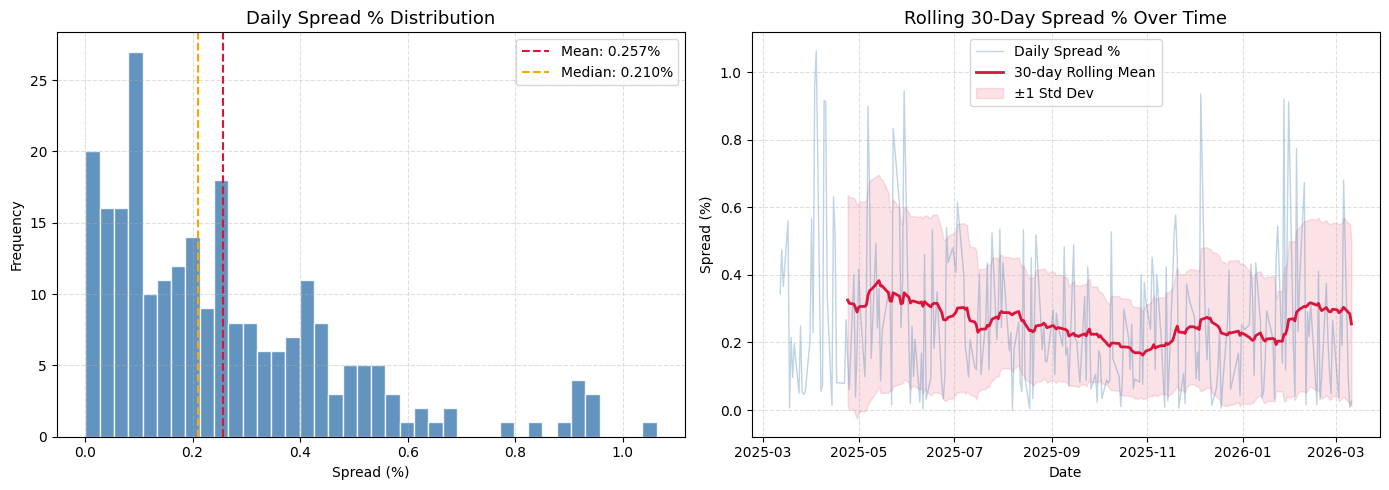

Top-10 Highest-Spread Days:


,TSX Price (CAD),NYSE Implied (CAD),CADUSD Rate,Spread (CAD),Spread %
2025-04-04 00:00:00,109.4200,108.2688,0.710177,1.1512,1.0633%
2025-04-03 00:00:00,115.8800,116.9876,0.703408,1.1076,0.9558%
2025-05-30 00:00:00,146.6400,148.0247,0.724338,1.3847,0.9443%
2025-12-05 00:00:00,222.7800,224.8629,0.716348,2.0829,0.9349%
2026-01-27 00:00:00,186.8200,188.5400,0.729288,1.7200,0.9207%
2025-04-09 00:00:00,129.0900,130.2724,0.701607,1.1824,0.9160%
2025-04-10 00:00:00,118.2600,119.3393,0.709154,1.0793,0.9126%
2026-01-30 00:00:00,178.6700,177.0555,0.741180,1.6145,0.9119%
2025-05-07 00:00:00,131.2900,130.1208,0.726248,1.1692,0.8985%
2025-05-23 00:00:00,139.5100,140.6726,0.721605,1.1626,0.8333%


In [19]:
# 11) Cell 10: Spread Distribution Analysis
spread_df = merged_portfolio.copy()
spread_df["Spread_CAD"]  = (spread_df["Close_domestic"] - spread_df["CAD_implied_close_price"]).abs()
spread_df["Spread_Pct"]  = spread_df["Spread_CAD"] / spread_df[["Close_domestic", "CAD_implied_close_price"]].min(axis=1) * 100
spread_df["Roll30_Mean"] = spread_df["Spread_Pct"].rolling(30).mean()
spread_df["Roll30_Std"]  = spread_df["Spread_Pct"].rolling(30).std()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# -- Left: histogram of daily spread %
axes[0].hist(spread_df["Spread_Pct"].dropna(), bins=40, color="steelblue", edgecolor="white", alpha=0.85)
axes[0].axvline(spread_df["Spread_Pct"].mean(), color="crimson", linewidth=1.5, linestyle="--", label=f"Mean: {spread_df['Spread_Pct'].mean():.3f}%")
axes[0].axvline(spread_df["Spread_Pct"].median(), color="orange", linewidth=1.5, linestyle="--", label=f"Median: {spread_df['Spread_Pct'].median():.3f}%")
axes[0].set_title("Daily Spread % Distribution", fontsize=13)
axes[0].set_xlabel("Spread (%)")
axes[0].set_ylabel("Frequency")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.4)

# -- Right: rolling 30-day mean spread over time with ±1σ band
axes[1].plot(spread_df.index, spread_df["Spread_Pct"], color="steelblue", alpha=0.35, linewidth=1, label="Daily Spread %")
axes[1].plot(spread_df.index, spread_df["Roll30_Mean"], color="crimson", linewidth=2, label="30-day Rolling Mean")
axes[1].fill_between(
    spread_df.index,
    spread_df["Roll30_Mean"] - spread_df["Roll30_Std"],
    spread_df["Roll30_Mean"] + spread_df["Roll30_Std"],
    color="crimson", alpha=0.12, label="±1 Std Dev"
)
axes[1].set_title("Rolling 30-Day Spread % Over Time", fontsize=13)
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Spread (%)")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

# -- Top-10 highest-spread days
top10 = (
    spread_df[["Close_domestic", "CAD_implied_close_price", "Exchange Rate", "Spread_CAD", "Spread_Pct"]]
    .nlargest(10, "Spread_Pct")
    .rename(columns={
        "Close_domestic":          "TSX Price (CAD)",
        "CAD_implied_close_price": "NYSE Implied (CAD)",
        "Exchange Rate":           "CADUSD Rate",
        "Spread_CAD":              "Spread (CAD)",
        "Spread_Pct":              "Spread %",
    })
)

print("Top-10 Highest-Spread Days:")
display(top10.style.format({
    "TSX Price (CAD)":    "{:.4f}",
    "NYSE Implied (CAD)": "{:.4f}",
    "CADUSD Rate":        "{:.6f}",
    "Spread (CAD)":       "{:.4f}",
    "Spread %":           "{:.4f}%",
}))

## Monthly P&L Breakdown

The chart and table below aggregate every trade from the trade log into calendar months, revealing the seasonality and consistency of the strategy.

**Bar Chart:** Net profit per month in CAD. Months where the strategy earns nothing appear as zero — these are periods where no mispricing survived fees, or where the FX rate kept the two prices too close together. Tall bars often cluster around earnings releases or macro FX moves.

**Summary Table:** For each month, shows total net profit, number of trades taken, total fees paid, average spread % on traded days, and the profit-to-fee ratio. A ratio below 1.0 would mean fees consumed more than the gross edge — a red flag for that period.

Together these help identify which market regimes are most favourable for cross-border arbitrage and whether performance is driven by a handful of outlier months or is broadly consistent.

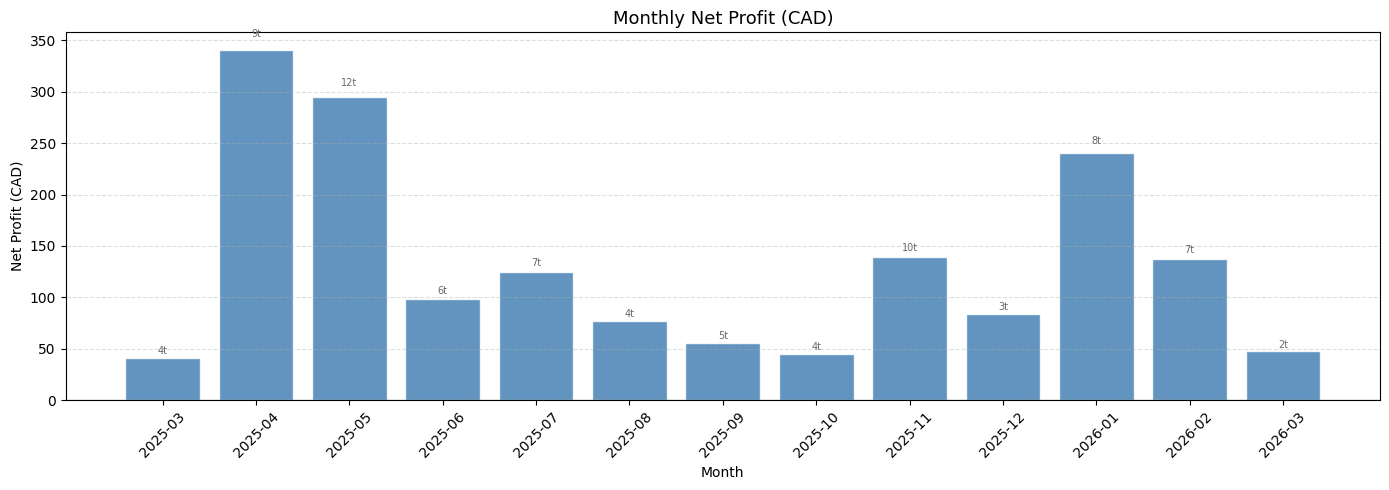

Best month:  2025-04  →  CAD 340.89
Worst month: 2025-03 →  CAD 41.21
Profitable months: 13 / 13



,Net Profit (CAD),Trades,Fees (CAD),Avg Spread %,Profit / Fee Ratio
Month,,,,,
2025-03,CAD 41.21,4,CAD 131.98,0.4356%,0.31x
2025-04,CAD 340.89,9,CAD 297.57,0.6999%,1.15x
2025-05,CAD 294.64,12,CAD 397.70,0.5524%,0.74x
2025-06,CAD 98.20,6,CAD 199.18,0.4665%,0.49x
2025-07,CAD 124.84,7,CAD 232.65,0.4742%,0.54x
2025-08,CAD 76.82,4,CAD 133.01,0.4847%,0.58x
2025-09,CAD 55.71,5,CAD 166.32,0.4085%,0.33x
2025-10,CAD 45.22,4,CAD 133.15,0.4073%,0.34x
2025-11,CAD 139.37,10,CAD 333.17,0.4283%,0.42x


In [20]:
# 12) Cell 11: Monthly P&L Breakdown
if trade_log.empty:
    print("No trades in log — run the trade log cell first.")
else:
    monthly = trade_log.copy()
    monthly.index = pd.to_datetime(monthly.index)
    monthly["Month"] = monthly.index.to_period("M")

    monthly_summary = monthly.groupby("Month").agg(
        Net_Profit   = ("Net Profit (CAD)", "sum"),
        Trades       = ("Net Profit (CAD)", "count"),
        Total_Fees   = ("Fees (CAD)",        "sum"),
        Avg_Spread   = ("Spread %",          "mean"),
    ).reset_index()

    monthly_summary["Profit_to_Fee"] = (
        monthly_summary["Net_Profit"] / monthly_summary["Total_Fees"].replace(0, float("nan"))
    ).round(2)

    # -- Bar chart
    fig, ax = plt.subplots(figsize=(14, 5))
    colors = ["steelblue" if v >= 0 else "crimson" for v in monthly_summary["Net_Profit"]]
    bars = ax.bar(
        monthly_summary["Month"].astype(str),
        monthly_summary["Net_Profit"],
        color=colors, edgecolor="white", alpha=0.85
    )
    ax.axhline(0, color="black", linewidth=0.8)
    ax.set_title("Monthly Net Profit (CAD)", fontsize=13)
    ax.set_xlabel("Month")
    ax.set_ylabel("Net Profit (CAD)")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, axis="y", linestyle="--", alpha=0.4)

    # annotate trade count above each bar
    for bar, n in zip(bars, monthly_summary["Trades"]):
        height = bar.get_height()
        offset = max(abs(height) * 0.03, 1)
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + (offset if height >= 0 else -offset * 3),
            f"{n}t", ha="center", va="bottom", fontsize=7, color="dimgray"
        )

    plt.tight_layout()
    plt.show()

    # -- Summary table
    display_summary = monthly_summary.rename(columns={
        "Month":          "Month",
        "Net_Profit":     "Net Profit (CAD)",
        "Trades":         "Trades",
        "Total_Fees":     "Fees (CAD)",
        "Avg_Spread":     "Avg Spread %",
        "Profit_to_Fee":  "Profit / Fee Ratio",
    }).set_index("Month")

    best  = display_summary["Net Profit (CAD)"].idxmax()
    worst = display_summary["Net Profit (CAD)"].idxmin()
    print(f"Best month:  {best}  →  CAD {display_summary.loc[best,  'Net Profit (CAD)']:,.2f}")
    print(f"Worst month: {worst} →  CAD {display_summary.loc[worst, 'Net Profit (CAD)']:,.2f}")
    print(f"Profitable months: {(display_summary['Net Profit (CAD)'] > 0).sum()} / {len(display_summary)}\n")

    display(display_summary.style.format({
        "Net Profit (CAD)":   "CAD {:,.2f}",
        "Fees (CAD)":         "CAD {:,.2f}",
        "Avg Spread %":       "{:.4f}%",
        "Profit / Fee Ratio": "{:.2f}x",
    }).background_gradient(subset=["Net Profit (CAD)"], cmap="RdYlGn"))

## Drawdown Analysis

Drawdown measures how far the strategy's equity has fallen from its most recent peak at any point in time. It answers the question: *how much pain would you have endured while running this strategy?*

**Drawdown Chart:** The shaded area shows the percentage decline from the rolling equity peak on each day. A flat line at 0% means the strategy is at an all-time high. Deep troughs represent extended periods where no profitable trades occurred and capital stagnated below a previous peak. Because this strategy only earns on mispricing days, drawdowns are caused by fee drag on marginal trades or long gaps between opportunities — not by losing trades in the traditional sense.

**Underwater Period Table:** Lists every distinct drawdown episode — when it started, when it recovered, how deep it went, and how many calendar days it lasted. Long shallow drawdowns suggest the strategy grinds slowly through low-spread regimes. Short deep ones suggest a cluster of fee-heavy marginal trades.

**Key stats** (max drawdown %, longest drawdown duration, average recovery time) give a quick read on the worst-case experience an investor would have faced.

In [ ]:
# 13) Cell 12: Drawdown Analysis
if trade_log.empty:
    print("No trades in log — run the trade log cell first.")
else:
    # Build a daily equity series by forward-filling "Capital After" across all trading days
    equity_series = pd.Series(
        trade_log["Capital After"].values,
        index=pd.to_datetime(trade_log.index)
    )
    all_days = pd.date_range(equity_series.index.min(), equity_series.index.max(), freq="B")
    equity_daily = equity_series.reindex(all_days).ffill().fillna(initial_capital)
    equity_daily.iloc[0] = initial_capital  # anchor start

    # Rolling peak and drawdown
    rolling_peak  = equity_daily.cummax()
    drawdown_pct  = (equity_daily - rolling_peak) / rolling_peak * 100  # always <= 0

    max_dd        = drawdown_pct.min()
    max_dd_date   = drawdown_pct.idxmin()

    # -- Drawdown chart
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={"height_ratios": [2, 1]})

    axes[0].plot(equity_daily.index, equity_daily, color="steelblue", linewidth=1.5, label="Strategy Equity")
    axes[0].plot(rolling_peak.index, rolling_peak, color="gray", linewidth=1, linestyle="--", alpha=0.6, label="Rolling Peak")
    axes[0].set_title("Strategy Equity vs Rolling Peak", fontsize=13)
    axes[0].set_ylabel("Capital (CAD)")
    axes[0].legend()
    axes[0].grid(True, linestyle="--", alpha=0.4)

    axes[1].fill_between(drawdown_pct.index, drawdown_pct, 0, color="crimson", alpha=0.4, label="Drawdown %")
    axes[1].plot(drawdown_pct.index, drawdown_pct, color="crimson", linewidth=0.8)
    axes[1].axhline(max_dd, color="darkred", linewidth=1, linestyle="--",
                    label=f"Max Drawdown: {max_dd:.2f}%")
    axes[1].set_title("Drawdown from Peak (%)", fontsize=13)
    axes[1].set_ylabel("Drawdown (%)")
    axes[1].legend()
    axes[1].grid(True, linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()

    # -- Identify drawdown episodes
    in_dd     = drawdown_pct < 0
    episodes  = []
    start     = None

    for date, val in drawdown_pct.items():
        if val < 0 and start is None:
            start = date
            trough_val  = val
            trough_date = date
        elif val < 0 and start is not None:
            if val < trough_val:
                trough_val  = val
                trough_date = date
        elif val == 0 and start is not None:
            episodes.append({
                "Start":          start,
                "Trough Date":    trough_date,
                "Recovery Date":  date,
                "Max Drawdown %": round(trough_val, 4),
                "Duration (days)": (date - start).days,
            })
            start = None

    # close any open episode at end of series
    if start is not None:
        episodes.append({
            "Start":           start,
            "Trough Date":     trough_date,
            "Recovery Date":   None,
            "Max Drawdown %":  round(trough_val, 4),
            "Duration (days)": (equity_daily.index[-1] - start).days,
        })

    dd_table = pd.DataFrame(episodes)

    print(f"Max drawdown:          {max_dd:.2f}%  (on {max_dd_date.date()})")
    print(f"Total drawdown episodes: {len(dd_table)}")
    if not dd_table.empty:
        print(f"Longest episode:       {dd_table['Duration (days)'].max()} days")
        recovered = dd_table[dd_table["Recovery Date"].notna()]
        if not recovered.empty:
            print(f"Avg recovery time:     {recovered['Duration (days)'].mean():.0f} days\n")
        display(dd_table.sort_values("Max Drawdown %").reset_index(drop=True).style.format({
            "Max Drawdown %":  "{:.4f}%",
            "Duration (days)": "{:,}",
        }))

## Equity Curve Comparison

The chart below plots the growth of $10,000 CAD over the backtest window across three scenarios run on the same data.

**Strategy:** The arbitrage simulator's compounding equity — capital grows only on days where a profitable mispricing is detected and the gross edge exceeds total fees. Flat periods represent days with no qualifying trade.

**SHOP.TO Buy & Hold:** A passive benchmark that simply holds the TSX-listed shares from day one. This reflects what a Canadian investor would have earned without any active trading.

**SHOP (USD→CAD) Buy & Hold:** The same passive benchmark using the NYSE price converted to CAD each day. Divergence between this line and the TSX benchmark reveals the FX drag (or tailwind) embedded in holding the US-listed shares.

Comparing the strategy line against both benchmarks shows whether the arbitrage alpha is genuine or whether a simple buy-and-hold would have outperformed.

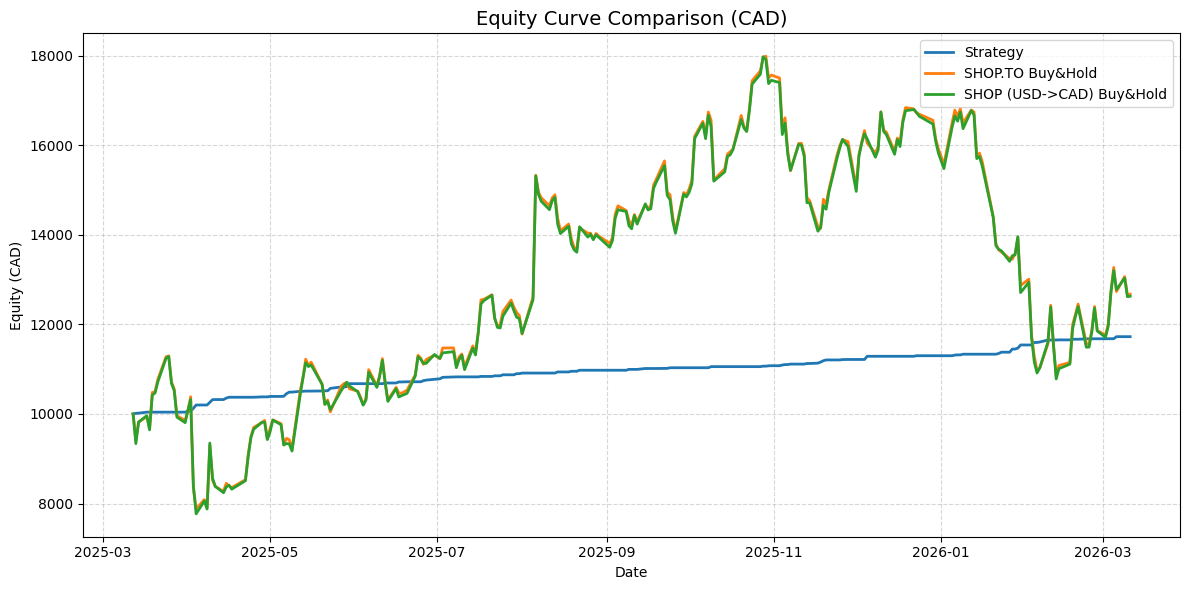

In [21]:
# 8) Cell 7: Plot Equity Curves (Strategy vs Benchmarks)
plt.figure(figsize=(12, 6))
for col in bench_df.columns:
    plt.plot(bench_df.index, bench_df[col], linewidth=2, label=col)

plt.title("Equity Curve Comparison (CAD)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Equity (CAD)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
# 9) Cell 8: Optional Parameter Sweep (fees/spread threshold)
spread_grid = [0.0000, 0.0005, 0.0010, 0.0020, 0.0030]
cad_fee_grid = [20, 30, 40]

results = []
for s in spread_grid:
    for fee in cad_fee_grid:
        eq = buy_sell_compounding(
            merged_portfolio,
            initial_capital=initial_capital,
            cad_fee=fee,
            usd_fee_rate=usd_fee_rate,
            min_rel_spread=s
        )
        results.append({
            "min_rel_spread": s,
            "cad_fee": fee,
            "final_equity": eq["Equity"].iloc[-1],
            "total_profit": eq["Profit"].iloc[-1],
            "trades_executed": int(eq["TradesExecuted"].sum())
        })

sensitivity_df = pd.DataFrame(results).sort_values(
    by=["total_profit", "trades_executed"],
    ascending=[False, False]
)

display(sensitivity_df)

,min_rel_spread,cad_fee,final_equity,total_profit,trades_executed
0,0.0000,20,12975.800387,2975.800387,125
3,0.0005,20,12975.800387,2975.800387,125
6,0.0010,20,12975.800387,2975.800387,125
9,0.0020,20,12973.941528,2973.941528,123
12,0.0030,20,12688.633206,2688.633206,80
1,0.0000,30,11725.672844,1725.672844,81
4,0.0005,30,11725.672844,1725.672844,81
7,0.0010,30,11725.672844,1725.672844,81
10,0.0020,30,11725.672844,1725.672844,81
13,0.0030,30,11725.565271,1725.565271,79
